<a href="https://colab.research.google.com/github/k-workproject/data-skills-roadmap/blob/main/python-project/02-house_price_advance_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup & Load Data

## Import Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Laod Data

In [3]:
path = '/content/drive/My Drive/House Prices - Advanced Regression Techniques'

In [4]:
train_path = os.path.join(path,'train.csv')
test_path = os.path.join(path,'test.csv')

In [5]:
train_data = pd.read_csv(train_path)
train_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [6]:
test_data = pd.read_csv(test_path)
test_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
print(train_data.shape)

(1460, 81)


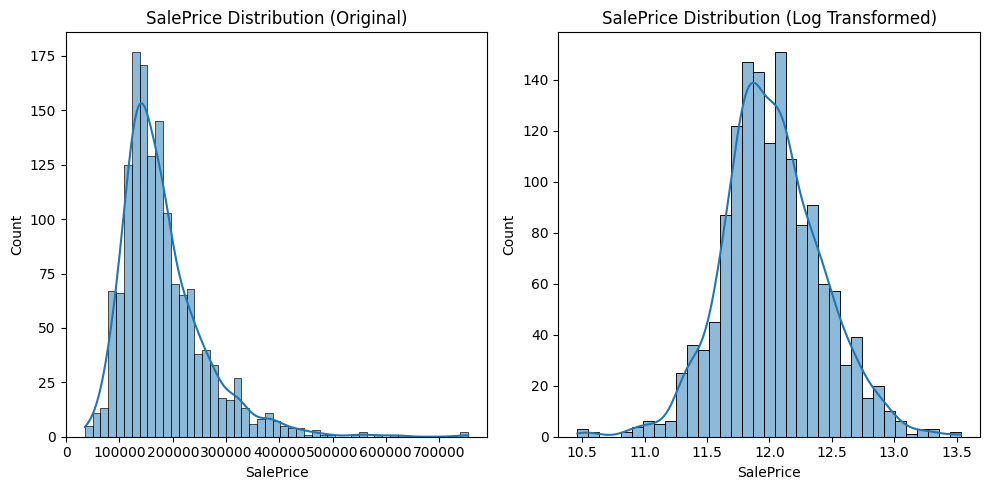

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_data['SalePrice'], kde = True)
plt.title('SalePrice Distribution (Original)')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train_data['SalePrice']), kde = True)
plt.title('SalePrice Distribution (Log Transformed)')

plt.tight_layout()
plt.show()

print(train_data['SalePrice'].describe())

# Data Cleaning

## Check Missing Value

In [11]:
missing = train_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(train_data)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent.round(2)})
print(missing_df)

              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtExposure             38       2.60
BsmtFinType2             38       2.60
BsmtQual                 37       2.53
BsmtCond                 37       2.53
BsmtFinType1             37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


In [12]:
# --- Categorical: เติมเป็น "None" ---
none_cols = [
    'Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in none_cols:
  train_data[col] = train_data[col].fillna('None')


# --- Numeric: เติมเป็น 0 (เพราะไม่มีสิ่งนั้น = ขนาด/จำนวน = 0) ---
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath'
]

for col in zero_cols:
  train_data[col] = train_data[col].fillna(0)

In [13]:
# LotFrontage: เติมด้วย median แยกตาม Neighborhood (คล้ายที่ทำกับ Age ใน Titanic)
train_data['LotFrontage'] = train_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical: หายแค่ 1 แถว เติมด้วย mode
train_data['Electrical'] = train_data['Electrical'].fillna(train_data['Electrical'].mode()[0])

In [14]:
remaining_missing = train_data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
print(remaining_missing)

Series([], dtype: int64)


In [15]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Check Outlier

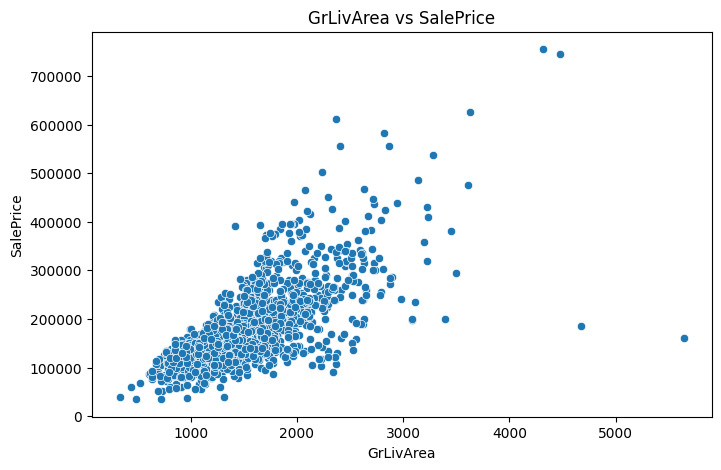

In [16]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = train_data, x = 'GrLivArea', y = 'SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.show()

In [17]:
outlier = train_data[(train_data['GrLivArea'] > 4000) & (train_data['SalePrice'] < 300000)]
print(outlier[['Id', 'GrLivArea', 'SalePrice']])

        Id  GrLivArea  SalePrice
523    524       4676     184750
1298  1299       5642     160000


In [18]:
train_data = train_data.drop(outlier.index)
train_data = train_data.reset_index(drop = True)

print(f"Shape หลังตัด outlier : {train_data.shape}")

Shape หลังตัด outlier : (1458, 81)


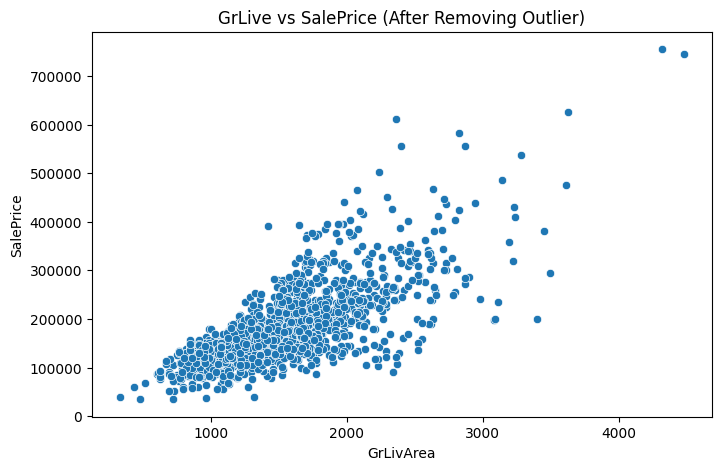

In [19]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = train_data, x = 'GrLivArea', y = 'SalePrice')
plt.title('GrLive vs SalePrice (After Removing Outlier)')
plt.show()

# Feature Engineering

In [20]:
train_data['TotalSF'] = train_data['TotalBsmtSF'] + train_data['1stFlrSF'] + train_data['2ndFlrSF']
train_data['HouseAge'] = train_data['YrSold'] - train_data['YearBuilt']
train_data['YearsSinceRemodel'] = train_data['YrSold'] - train_data['YearRemodAdd']
train_data['TotalBath'] = (train_data['FullBath'] + 0.5 * train_data['HalfBath'] +
                             train_data['BsmtFullBath'] + 0.5 * train_data['BsmtHalfBath'])

In [21]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_cols:
    train_data[col] = train_data[col].replace(quality_map)

/tmp/ipykernel_3200/1117148934.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data[col] = train_data[col].replace(quality_map)


In [22]:
train_data[['TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBath'] + ordinal_cols].head()

,TotalSF,HouseAge,YearsSinceRemodel,TotalBath,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,PoolQC
0,2566,5,5,3.5,4,3,4,3,5,4,0,3,3,0
1,2524,31,31,2.5,3,3,4,3,5,3,3,3,3,0
2,2706,7,6,3.5,4,3,4,3,5,4,3,3,3,0
3,2473,91,36,2.0,3,3,3,4,4,4,4,3,3,0
4,3343,8,8,3.5,4,3,4,3,5,4,3,3,3,0


In [23]:
print(train_data['MSSubClass'].dtype)

int64


In [24]:
train_data['MSSubClass'] = train_data['MSSubClass'].astype(str)

## One-Hot Encoding

In [25]:
object_cols = train_data.select_dtypes(include = 'object').columns.tolist()
print(f"จำนวนคอลัมน์ object ที่เหลือ : {len(object_cols)}")
print(object_cols)

จำนวนคอลัมน์ object ที่เหลือ : 34
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [26]:
train_data = pd.get_dummies(train_data, columns = object_cols, drop_first = True)
print(f"Shape หลัง Endcoding : {train_data.shape}")

Shape หลัง Endcoding : (1458, 247)


In [27]:
print(train_data.select_dtypes(include = 'object').columns.tolist())
train_data.info()

[]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Columns: 247 entries, Id to SaleCondition_Partial
dtypes: bool(196), float64(4), int64(47)
memory usage: 860.1 KB


# EDA

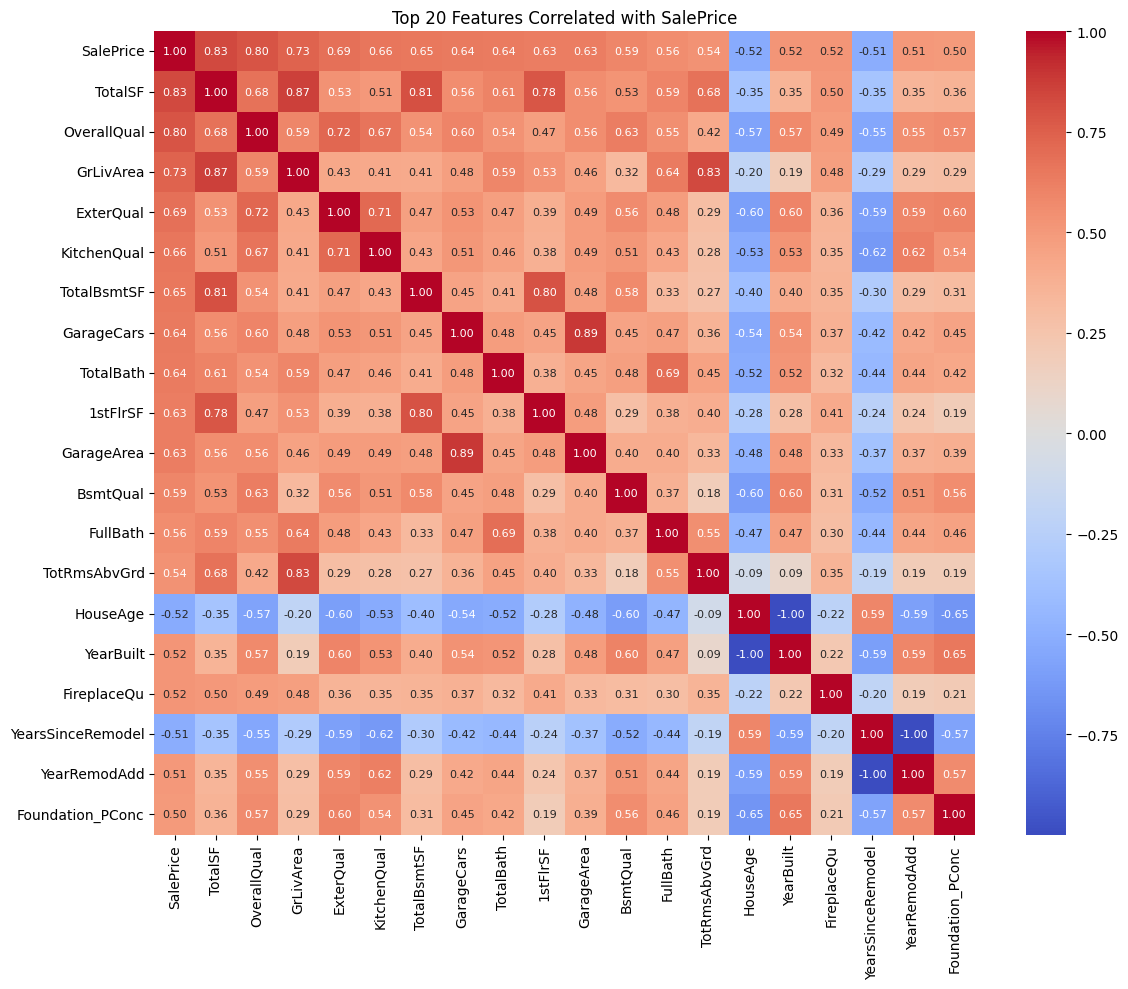

In [28]:
plt.figure(figsize=(12, 10))

corr_matrix = train_data.corr(numeric_only=True)
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(20).index

sns.heatmap(train_data[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 8})
plt.title('Top 20 Features Correlated with SalePrice')
plt.tight_layout()
plt.show()

In [29]:
# ตัดคอลัมน์ดิบที่ใช้สร้างฟีเจอร์ใหม่ไปแล้ว (ซ้ำซ้อน 100%)
cols_to_drop = ['YearBuilt', 'YearRemodAdd']
train_data_model = train_data.drop(columns=cols_to_drop)

print(f"Shape หลังตัดคอลัมน์ซ้ำซ้อน: {train_data_model.shape}")

Shape หลังตัดคอลัมน์ซ้ำซ้อน: (1458, 245)


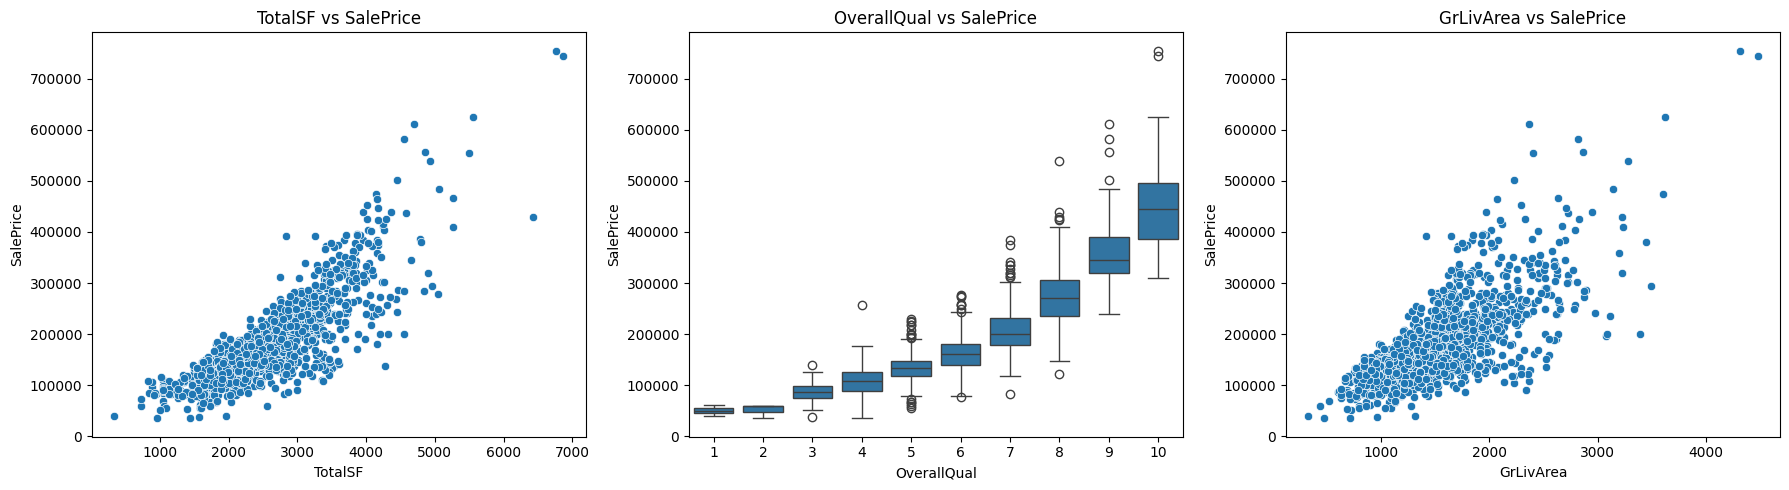

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=train_data_model, x='TotalSF', y='SalePrice', ax=axes[0])
axes[0].set_title('TotalSF vs SalePrice')

sns.boxplot(data=train_data_model, x='OverallQual', y='SalePrice', ax=axes[1])
axes[1].set_title('OverallQual vs SalePrice')

sns.scatterplot(data=train_data_model, x='GrLivArea', y='SalePrice', ax=axes[2])
axes[2].set_title('GrLivArea vs SalePrice')

plt.tight_layout()
plt.show()

## Neighborhood vs SalePrice

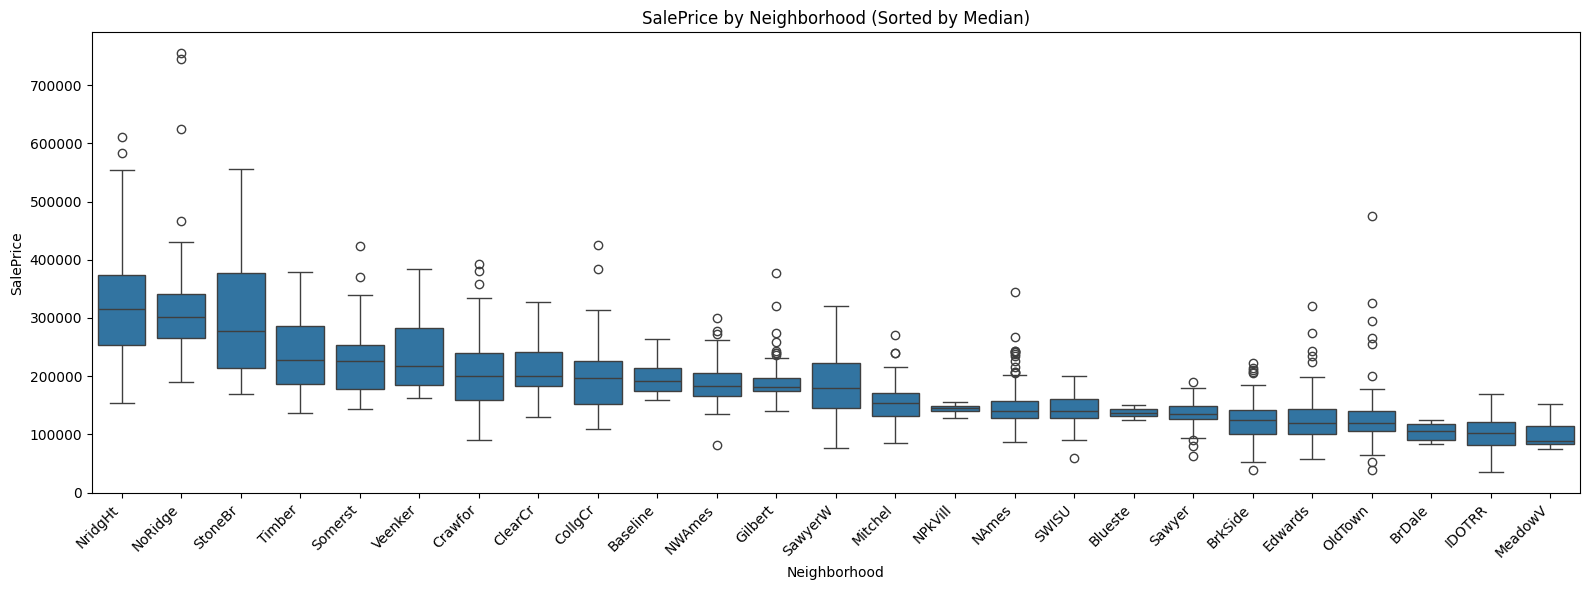

In [31]:
neighborhood_cols = [col for col in train_data.columns if col.startswith('Neighborhood_')]

# ถ้าทุกคอลัมน์เป็น False แปลว่าเป็นกลุ่ม baseline ที่ถูก drop_first ตัดไป
neighborhood_series = train_data[neighborhood_cols].idxmax(axis=1).str.replace('Neighborhood_', '')
is_baseline = ~train_data[neighborhood_cols].any(axis=1)  # เช็คว่าแถวไหนไม่มีคอลัมน์ไหนเป็น True เลย

neighborhood_series[is_baseline] = 'Baseline'  # ตั้งชื่อกลุ่มที่ถูก drop ไว้ให้ชัดเจน

temp_df = train_data.copy()
temp_df['Neighborhood'] = neighborhood_series

plt.figure(figsize=(16, 6))
order = temp_df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(data=temp_df, x='Neighborhood', y='SalePrice', order=order)
plt.xticks(rotation=45, ha='right')
plt.title('SalePrice by Neighborhood (Sorted by Median)')
plt.tight_layout()
plt.show()

## OverallCond, YrSold, MoSold vs SalePrice

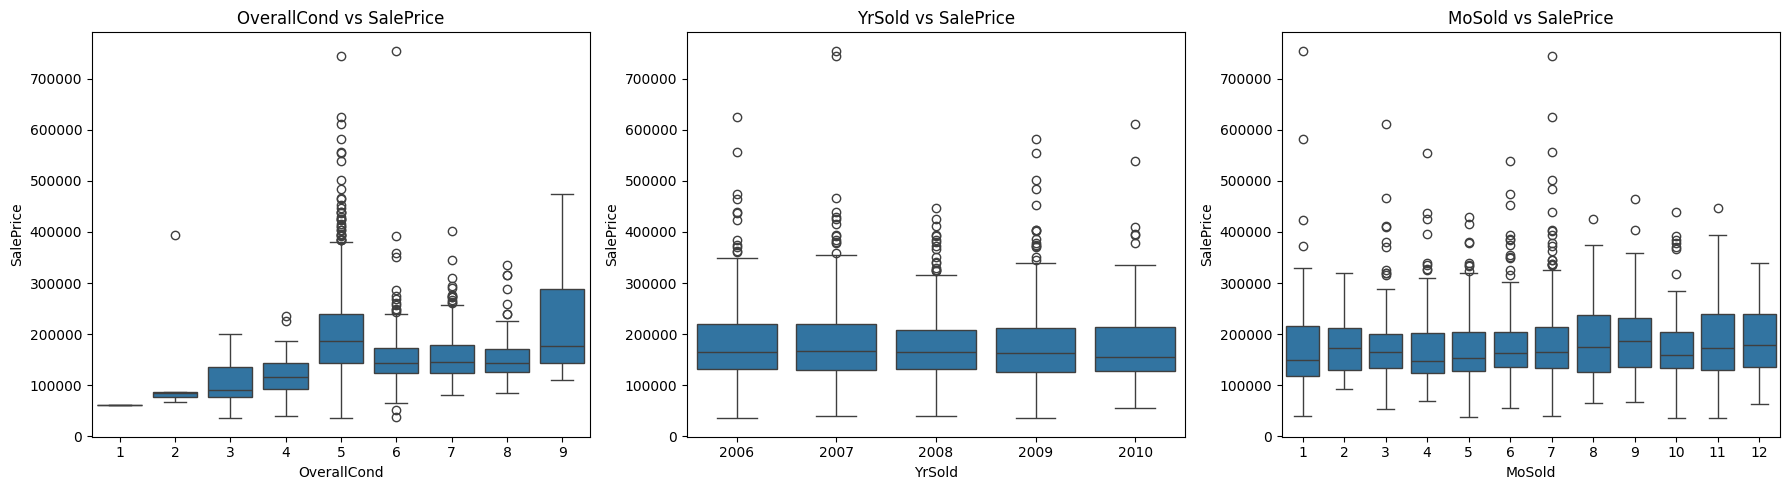

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=temp_df, x='OverallCond', y='SalePrice', ax=axes[0])
axes[0].set_title('OverallCond vs SalePrice')

sns.boxplot(data=temp_df, x='YrSold', y='SalePrice', ax=axes[1])
axes[1].set_title('YrSold vs SalePrice')

sns.boxplot(data=temp_df, x='MoSold', y='SalePrice', ax=axes[2])
axes[2].set_title('MoSold vs SalePrice')

plt.tight_layout()
plt.show()

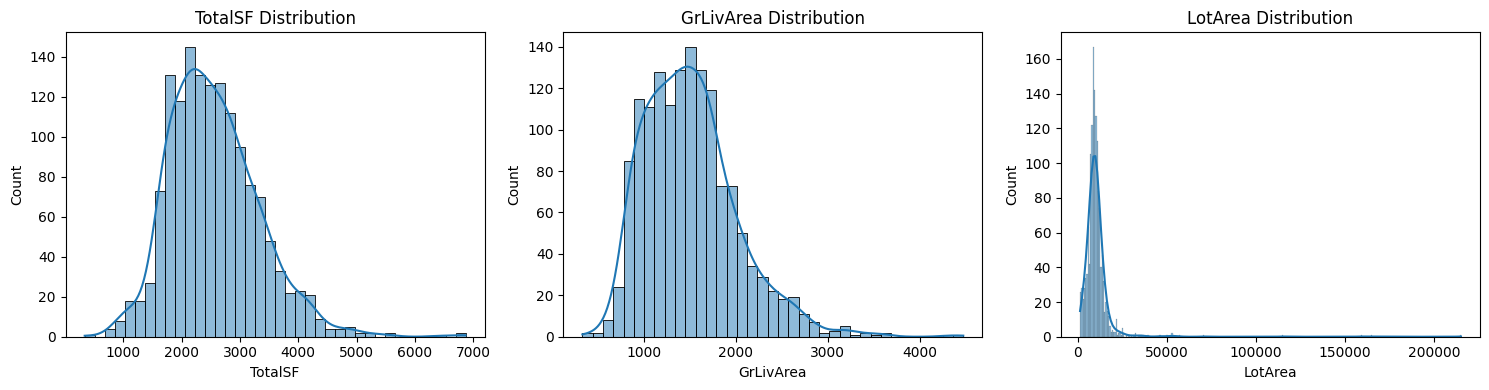

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(temp_df['TotalSF'], kde=True, ax=axes[0])
axes[0].set_title('TotalSF Distribution')

sns.histplot(temp_df['GrLivArea'], kde=True, ax=axes[1])
axes[1].set_title('GrLivArea Distribution')

sns.histplot(temp_df['LotArea'], kde=True, ax=axes[2])
axes[2].set_title('LotArea Distribution')

plt.tight_layout()
plt.show()

## Log Transform LotArea

In [34]:
train_data_model['LotArea_log'] = np.log1p(train_data_model['LotArea'])
train_data_model = train_data_model.drop('LotArea', axis=1)

print(f"Shape หลัง Log Transform LotArea: {train_data_model.shape}")

Shape หลัง Log Transform LotArea: (1458, 245)


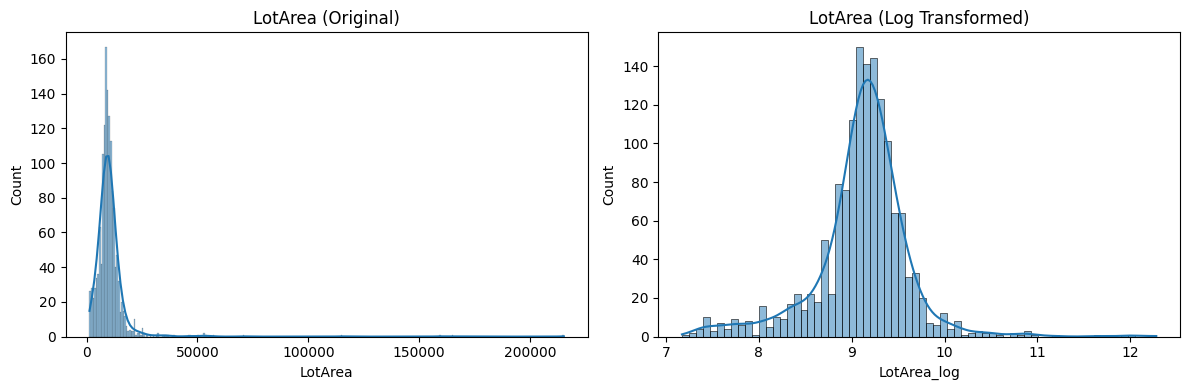

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(temp_df['LotArea'], kde=True, ax=axes[0])
axes[0].set_title('LotArea (Original)')

sns.histplot(train_data_model['LotArea_log'], kde=True, ax=axes[1])
axes[1].set_title('LotArea (Log Transformed)')

plt.tight_layout()
plt.show()

In [36]:
from scipy.stats import skew

numeric_cols = train_data_model.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['Id', 'SalePrice']]

skewness = train_data_model[numeric_cols].apply(lambda x: skew(x)).sort_values(ascending=False)
print(skewness.head(10))

MiscVal          24.434913
PoolQC           17.535394
PoolArea         15.932532
3SsnPorch        10.286510
LowQualFinSF      8.995688
KitchenAbvGr      4.480268
BsmtFinSF2        4.247550
ScreenPorch       4.114690
BsmtHalfBath      4.095895
EnclosedPorch     3.083987
dtype: float64


# Modeling

## Train/ Validation Split

In [37]:
from sklearn.model_selection import train_test_split

X = train_data_model.drop(['Id', 'SalePrice'], axis=1)
y_log = np.log1p(train_data_model['SalePrice'])

X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (1166, 243)
Validation shape: (292, 243)


## Baseline Model - Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr = r2_score(y_val, y_pred_lr)

print(f"RMSE (log scale): {rmse_lr:.4f}")
print(f"R² score: {r2_lr:.4f}")

RMSE (log scale): 0.1325
R² score: 0.8958


## Ridge, Lasso, Random Forest Model

In [40]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.001, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,RMSE,R2
0,Lasso,0.124891,0.907474
1,Ridge,0.130089,0.899611
2,Linear Regression,0.132538,0.895796
3,Random Forest,0.146673,0.872385


## Cross - Validation

### GridSearchCV สำหรับ Lasso

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

param_grid_lasso = {
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
}

lasso = Lasso(random_state=42, max_iter=5000)

grid_search_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_lasso.fit(X_train_scaled, y_train)

print(f"Best alpha: {grid_search_lasso.best_params_}")
print(f"Best CV RMSE: {-grid_search_lasso.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best alpha: {'alpha': 0.005}
Best CV RMSE: 0.1146


In [42]:
best_lasso = grid_search_lasso.best_estimator_

y_pred_lasso_tuned = best_lasso.predict(X_val_scaled)

rmse_tuned = np.sqrt(mean_squared_error(y_val, y_pred_lasso_tuned))
r2_tuned = r2_score(y_val, y_pred_lasso_tuned)

print(f"RMSE: {rmse_tuned:.4f}")
print(f"R²:   {r2_tuned:.4f}")

RMSE: 0.1222
R²:   0.9114


## Test

In [44]:
test_ids = test_data['Id']

# --- Data Cleaning: None-group ---
none_cols = [
    'Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    test_data[col] = test_data[col].fillna('None')

# --- Data Cleaning: Zero-group ---
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']
for col in zero_cols:
    test_data[col] = test_data[col].fillna(0)

# --- Data Cleaning: Median/Mode ---
test_data['LotFrontage'] = test_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
test_data['LotFrontage'] = test_data['LotFrontage'].fillna(test_data['LotFrontage'].median())
test_data['Electrical'] = test_data['Electrical'].fillna(test_data['Electrical'].mode()[0])

# --- test.csv มักมี missing เพิ่มเติมที่ train ไม่มี เติมด้วย mode/0 เผื่อไว้ ---
for col in test_data.columns:
    if test_data[col].isnull().sum() > 0:
        if test_data[col].dtype == 'object':
            test_data[col] = test_data[col].fillna(test_data[col].mode()[0])
        else:
            test_data[col] = test_data[col].fillna(0)

# --- Feature Engineering ---
test_data['TotalSF'] = test_data['TotalBsmtSF'] + test_data['1stFlrSF'] + test_data['2ndFlrSF']
test_data['HouseAge'] = test_data['YrSold'] - test_data['YearBuilt']
test_data['YearsSinceRemodel'] = test_data['YrSold'] - test_data['YearRemodAdd']
test_data['TotalBath'] = (test_data['FullBath'] + 0.5 * test_data['HalfBath'] +
                           test_data['BsmtFullBath'] + 0.5 * test_data['BsmtHalfBath'])

# --- Ordinal Encoding ---
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in ordinal_cols:
    test_data[col] = test_data[col].map(quality_map).fillna(0).astype(int)

# --- Log Transform LotArea ---
test_data['LotArea_log'] = np.log1p(test_data['LotArea'])
test_data = test_data.drop('LotArea', axis=1)

# --- MSSubClass เป็น category ---
test_data['MSSubClass'] = test_data['MSSubClass'].astype(str)

# --- One-Hot Encoding ---
object_cols_test = test_data.select_dtypes(include='object').columns.tolist()
test_data = pd.get_dummies(test_data, columns=object_cols_test, drop_first=True)

# --- ตัดคอลัมน์ดิบที่ซ้ำซ้อน (เหมือน train) ---
test_data = test_data.drop(columns=['YearBuilt', 'YearRemodAdd'], errors='ignore')

print(f"Test shape ก่อนจัดคอลัมน์: {test_data.shape}")

Test shape ก่อนจัดคอลัมน์: (1459, 230)


In [45]:
missing_cols = set(X_train.columns) - set(test_data.columns)
extra_cols = set(test_data.columns) - set(X_train.columns) - {'Id'}

print(f"คอลัมน์ที่ขาดใน test: {missing_cols}")
print(f"คอลัมน์ที่เกินใน test: {extra_cols}")

for col in missing_cols:
    test_data[col] = False

test_data = test_data[X_train.columns]

print(f"Test shape หลังจัดคอลัมน์: {test_data.shape}")
print(list(test_data.columns) == list(X_train.columns))

คอลัมน์ที่ขาดใน test: {'MiscFeature_TenC', 'RoofMatl_Metal', 'Condition2_RRAe', 'Exterior1st_ImStucc', 'Condition2_RRNn', 'HouseStyle_2.5Fin', 'Exterior1st_Stone', 'Condition2_RRAn', 'RoofMatl_Roll', 'Utilities_NoSeWa', 'Heating_OthW', 'Exterior2nd_Other', 'Heating_GasA', 'Electrical_Mix', 'RoofMatl_Membran'}
คอลัมน์ที่เกินใน test: {'MSSubClass_150'}
Test shape หลังจัดคอลัมน์: (1459, 243)
True


In [46]:
test_scaled = scaler.transform(test_data)

test_predictions_log = best_lasso.predict(test_scaled)

# แปลงกลับจาก log scale เป็นราคาจริง
test_predictions = np.expm1(test_predictions_log)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f"\nจำนวนแถวทั้งหมด: {len(submission)}")

     Id      SalePrice
0  1461  118321.693535
1  1462  157904.997801
2  1463  179602.209016
3  1464  195160.475377
4  1465  196332.189327

จำนวนแถวทั้งหมด: 1459


In [47]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Summary

## 🎯 Summary: Model Results & Conclusion

### Models Tried

| Model | RMSE (Validation, log scale) | R² |
|---|---|---|
| **Lasso (Tuned)** ⭐ | **0.1222** | 0.9114 |
| Lasso (Default) | 0.1249 | 0.9075 |
| Ridge | 0.1301 | - |
| Linear Regression | 0.1325 | 0.8958 |
| Random Forest | 0.1467 | 0.8726 |

### Final Model: Lasso (Tuned)
- **Hyperparameter:** `alpha=0.005` (หาด้วย GridSearchCV + 5-Fold Cross-Validation)
- **Validation Metrics:** RMSE = 0.1222, R² = 0.9114 (log scale)
- **Kaggle Leaderboard Score:** **0.13599** (RMSE บน test.csv จริง, log scale)

### ทำไมเลือก Lasso แทน Tree-based Models
- ฟีเจอร์ส่วนใหญ่ในชุดข้อมูลนี้ (OverallQual, TotalSF, GrLivArea) มีความสัมพันธ์กับ SalePrice แบบค่อนข้างเป็นเส้นตรง ทำให้ Linear-based model ทำงานได้ดีกว่า Tree-based model เช่นเดียวกับที่พบในโปรเจกต์ Titanic
- Dataset นี้มีฟีเจอร์เยอะมาก (243 คอลัมน์ หลัง One-Hot Encoding) บนข้อมูลแค่ 1,458 แถว ทำให้เสี่ยง Overfitting สูง — Lasso มีจุดเด่นคือทำ Feature Selection ในตัว (บีบค่าสัมประสิทธิ์ของฟีเจอร์ที่ไม่สำคัญให้เป็น 0) จึงเหมาะกับสถานการณ์นี้มากกว่า Ridge หรือ Random Forest
- การทำ Feature Scaling (StandardScaler) ก่อนเข้า Linear-based model ช่วยแก้ปัญหา ConvergenceWarning และทำให้ผลลัพธ์น่าเชื่อถือขึ้น

### สิ่งที่เรียนรู้จากโปรเจกต์นี้
- Missing Value ไม่ได้แปลว่า "ข้อมูลหาย" เสมอไป — ต้องอ่าน Data Dictionary ให้ดี บาง NA หมายถึง "ไม่มีสิ่งนั้นจริงๆ" (เช่น ไม่มีสระว่ายน้ำ ไม่มีโรงรถ) ต้องเติมด้วย "None"/0 ไม่ใช่ median/mode
- Target ที่เบ้ขวาแรง (SalePrice) ควร Log Transform ก่อนเทรน แล้วแปลงกลับด้วย `np.expm1()` ตอน Predict เสมอ — ลืมขั้นตอนนี้จะทำให้ผลลัพธ์ผิดฟอร์แมตทันที
- Feature Engineering แบบรวมฟีเจอร์ (เช่น TotalSF) ให้ Correlation กับ Target สูงกว่าฟีเจอร์ย่อยที่เอามารวมกันเสียอีก
- Outlier ควรพิจารณาจากแนวโน้มความสัมพันธ์ ไม่ใช่ค่าคงที่ตายตัว — จุดที่ "ขนาดใหญ่ผิดปกติแต่ราคาต่ำผิดปกติ" คือสัญญาณของข้อมูลที่ควรพิจารณาตัดออก
- เมื่อฟีเจอร์เยอะมากกว่าจำนวนตัวอย่างมาก Regularization (Lasso/Ridge) ช่วยป้องกัน Overfitting ได้ดีกว่าการเพิ่มความซับซ้อนของโมเดล

### แนวทางพัฒนาต่อ (ถ้ามีเวลา)
- ลอง Gradient Boosting models เช่น XGBoost, LightGBM ซึ่งมักทำผลงานดีใน Competition ลักษณะนี้
- ลอง Log Transform เพิ่มเติมกับฟีเจอร์ที่เบ้แรง (เช่น MiscVal, PoolArea) หรือแปลงเป็น Binary feature (เช่น HasPool) แทน
- ลอง Ensemble หลายโมเดลเข้าด้วยกัน (Stacking Lasso + Random Forest + Gradient Boosting)
- ทำ Feature Selection อย่างเป็นระบบมากขึ้น โดยดูจากค่าสัมประสิทธิ์ที่ Lasso บีบเหลือ (ฟีเจอร์ที่ถูกบีบเป็น 0 คือฟีเจอร์ที่โมเดลเห็นว่าไม่สำคัญ)

---

**🔗 Kaggle Submission Score: 0.13599 (RMSE, log scale)**